<a href="https://colab.research.google.com/github/karenmunarco11-cyber/Tarea2_Modelos_No_Supervisados/blob/main/MODELO_NO_SUPERVISADO_KM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


*   **MODELO NO SUPERVISADO:**
*   Base de datos Abalones
*   **Estudiante:** Karen Munarco





Instalación de librerías

In [ ]:
install.packages(c("cluster",
                   "factoextra",
                   "dbscan",
                   "ggplot2",
                   "NbClust",
                   "clusterCrit",
                   "Rtsne"))

library(cluster)
library(factoextra)
library(dbscan)
library(ggplot2)
library(NbClust)
library(clusterCrit)
library(Rtsne)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘lazyeval’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘irlba’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’


Loading required package: ggplot2

Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/


Attaching package: ‘dbscan’


The following object is masked from ‘package:stats’:

  

Carga de datos

In [ ]:
abalone <- read.csv(
"https://raw.githubusercontent.com/karenmunarco11-cyber/Tarea2_Modelos_No_Supervisados/refs/heads/main/abalone.data.txt",
header = FALSE
)

head(abalone)

,V1,V2,V3,V4,V5,V6,V7,V8,V9
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,sex,length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
2,M,0.455,0.365,0.095,0.514,0.2245,0.101,0.15,15
3,M,0.35,0.265,0.09,0.2255,0.0995,0.0485,0.07,7
4,F,0.53,0.42,0.135,0.677,0.2565,0.1415,0.21,9
5,M,0.44,0.365,0.125,0.516,0.2155,0.114,0.155,10
6,I,0.33,0.255,0.08,0.205,0.0895,0.0395,0.055,7


Asignación de nombres a las variables

In [ ]:
colnames(abalone) <- c(
  "Sex",
  "Length",
  "Diameter",
  "Height",
  "Whole_weight",
  "Shucked_weight",
  "Viscera_weight",
  "Shell_weight",
  "Rings"
)

# Remove the first row which contains string headers that were read as data
abalone <- abalone[-1, ]

head(abalone)

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
2,M,0.455,0.365,0.095,0.514,0.2245,0.101,0.15,15
3,M,0.35,0.265,0.09,0.2255,0.0995,0.0485,0.07,7
4,F,0.53,0.42,0.135,0.677,0.2565,0.1415,0.21,9
5,M,0.44,0.365,0.125,0.516,0.2155,0.114,0.155,10
6,I,0.33,0.255,0.08,0.205,0.0895,0.0395,0.055,7
7,I,0.425,0.3,0.095,0.3515,0.141,0.0775,0.12,8


Conversión de factores a valores numéricos

In [ ]:
abalone$Sex <- as.factor(abalone$Sex)

abalone$Sex <- as.numeric(abalone$Sex)

# Convert remaining columns to numeric
numeric_cols <- c(
  "Length", "Diameter", "Height", "Whole_weight",
  "Shucked_weight", "Viscera_weight", "Shell_weight", "Rings"
)
abalone[numeric_cols] <- lapply(abalone[numeric_cols], as.numeric)

str(abalone)

'data.frame':	4177 obs. of  9 variables:
 $ Sex           : num  3 3 1 3 2 2 1 1 3 1 ...
 $ Length        : num  0.455 0.35 0.53 0.44 0.33 0.425 0.53 0.545 0.475 0.55 ...
 $ Diameter      : num  0.365 0.265 0.42 0.365 0.255 0.3 0.415 0.425 0.37 0.44 ...
 $ Height        : num  0.095 0.09 0.135 0.125 0.08 0.095 0.15 0.125 0.125 0.15 ...
 $ Whole_weight  : num  0.514 0.226 0.677 0.516 0.205 ...
 $ Shucked_weight: num  0.2245 0.0995 0.2565 0.2155 0.0895 ...
 $ Viscera_weight: num  0.101 0.0485 0.1415 0.114 0.0395 ...
 $ Shell_weight  : num  0.15 0.07 0.21 0.155 0.055 0.12 0.33 0.26 0.165 0.32 ...
 $ Rings         : num  15 7 9 10 7 8 20 16 9 19 ...


Estandarización de variables

In [ ]:
datos <- scale(abalone)

summary(datos)

      Sex               Length           Diameter           Height        
 Min.   :-1.28054   Min.   :-3.7387   Min.   :-3.5558   Min.   :-3.33555  
 1st Qu.:-1.28054   1st Qu.:-0.6161   1st Qu.:-0.5832   1st Qu.:-0.58614  
 Median :-0.06435   Median : 0.1749   Median : 0.1725   Median : 0.01156  
 Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.00000  
 3rd Qu.: 1.15184   3rd Qu.: 0.7578   3rd Qu.: 0.7267   3rd Qu.: 0.60926  
 Max.   : 1.15184   Max.   : 2.4232   Max.   : 2.4397   Max.   :23.68045  
  Whole_weight      Shucked_weight    Viscera_weight      Shell_weight    
 Min.   :-1.68589   Min.   :-1.6145   Min.   :-1.64298   Min.   :-1.7049  
 1st Qu.:-0.78966   1st Qu.:-0.7811   1st Qu.:-0.79455   1st Qu.:-0.7818  
 Median :-0.05963   Median :-0.1053   Median :-0.08752   Median :-0.0347  
 Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.66123   3rd Qu.: 0.6426   3rd Qu.: 0.66056   3rd Qu.: 0.6478  
 Max.   : 4.07178   Max. 

Método del Codo (Elbow)

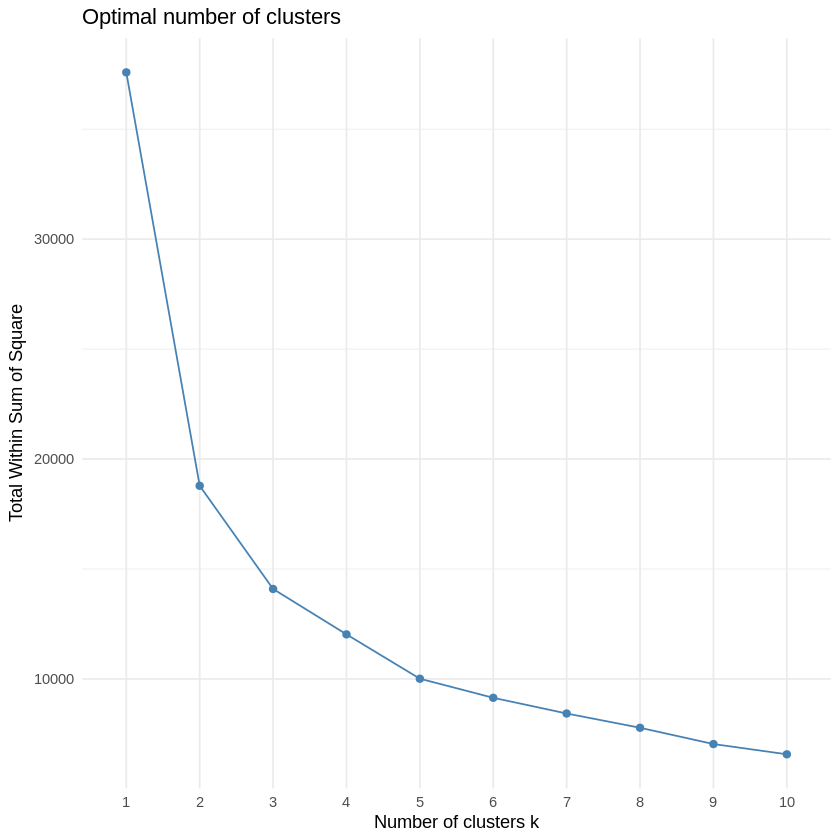

In [ ]:
library(factoextra)
factoextra::fviz_nbclust(
  datos,
  kmeans,
  method = "wss"
)+
theme_minimal()



*   Se observa la variación de la suma de cuadrados dentro de los grupos para diferentes números de clusters. El punto de inflexión sugiere que tres conglomerados proporcionan una segmentación adecuada de los datos.



Método Silhouette

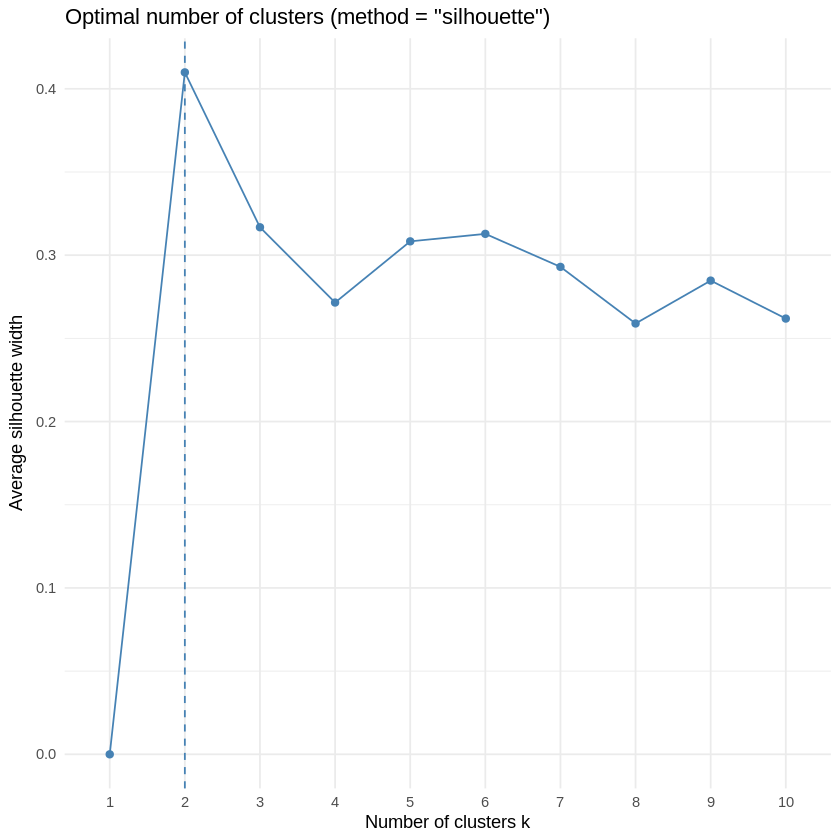

In [ ]:
fviz_nbclust(
  datos,
  kmeans,
  method = "silhouette"
)+
theme_minimal()



*   Se observa el grado de cohesión y separación de los clusters. Los resultados indican que las observaciones presentan una asignación adecuada a sus respectivos grupos.



Índice Calinski-Harabasz

In [ ]:
set.seed(123)

nb <- NbClust(
  datos,
  distance = "euclidean",
  min.nc = 2,
  max.nc = 10,
  method = "kmeans",
  index = "ch"
)

nb$Best.nc

Number_clusters     Value_Index 
          2.000        4178.872

K-Means

In [ ]:
set.seed(123)

modelo_kmeans <- kmeans(
  datos,
  centers = 3,
  nstart = 25
)

modelo_kmeans

K-means clustering with 3 clusters of sizes 1176, 1223, 1778

Cluster means:
          Sex     Length   Diameter      Height Whole_weight Shucked_weight
1  0.02459191 -1.2793008 -1.2804676 -1.12274520   -1.1389555    -1.08557780
2 -0.07628027  1.0356703  1.0410798  0.98117376    1.2201617     1.17444837
3  0.03620398  0.1337643  0.1308151  0.06770127   -0.0859652    -0.08982613
  Viscera_weight Shell_weight      Rings
1    -1.11731946  -1.12959651 -0.8592661
2     1.19796465   1.17722117  0.6226237
3    -0.08500735  -0.06261867  0.1400609

Clustering vector:
   2    3    4    5    6    7    8    9   10   11   12   13   14   15   16   17 
   3    1    3    3    1    1    3    3    3    3    3    1    3    3    1    3 
  18   19   20   21   22   23   24   25   26   27   28   29   30   31   32   33 
   1    1    1    1    1    1    3    3    2    3    3    3    3    3    3    2 
  34   35   36   37   38   39   40   41   42   43   44   45   46   47   48   49 
   2    2    2    1    2    1 

Visualización de K-Means

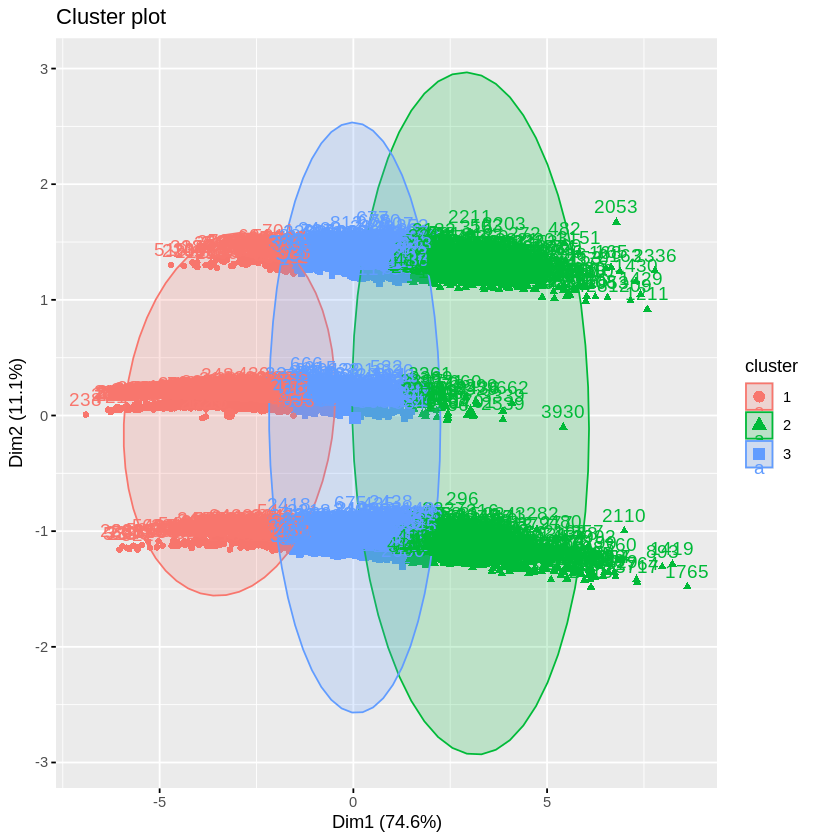

In [29]:
fviz_cluster(
  modelo_kmeans,
  data = datos,
  ellipse.type = "norm"
)



*   Se observa la formación de tres conglomerados claramente diferenciados, los cuales agrupan abalones con características físicas similares, principalmente relacionadas con el tamaño y el peso.



Clustering Jerárquico
Matriz de distancias

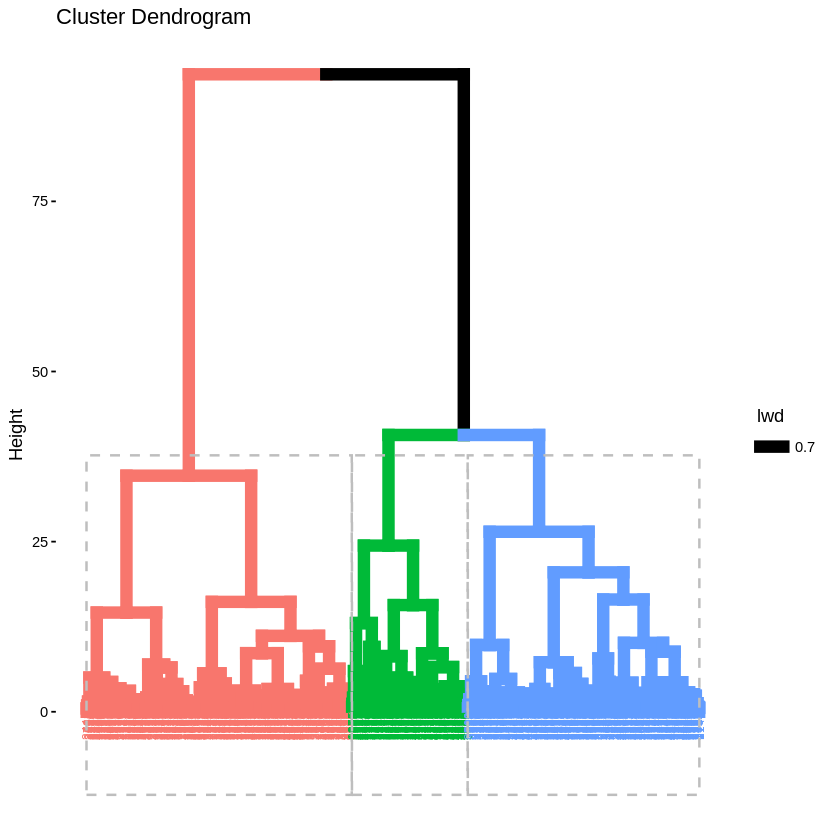

In [30]:
# Seleccionar una muestra de 1000 observaciones
set.seed(123)

datos_hc <- datos[sample(1:nrow(datos),1000),]

# Calcular matriz de distancias
distancia <- dist(datos_hc)

# Aplicar método jerárquico de Ward
hc <- hclust(
  distancia,
  method = "ward.D2"
)

# Graficar el dendrograma
fviz_dend(
  hc,
  k = 3,
  rect = TRUE,
  cex = 0.5
)



*   Se observa la formación progresiva de los grupos mediante una estructura jerárquica, evidenciándose la existencia de tres conglomerados principales.



DBSCAN

DBSCAN clustering for 4177 objects.
Parameters: eps = 1.5, minPts = 5
Using euclidean distances and borderpoints = TRUE
The clustering contains 1 cluster(s) and 19 noise points.

   0    1 
  19 4158 

Available fields: cluster, eps, minPts, metric, borderPoints

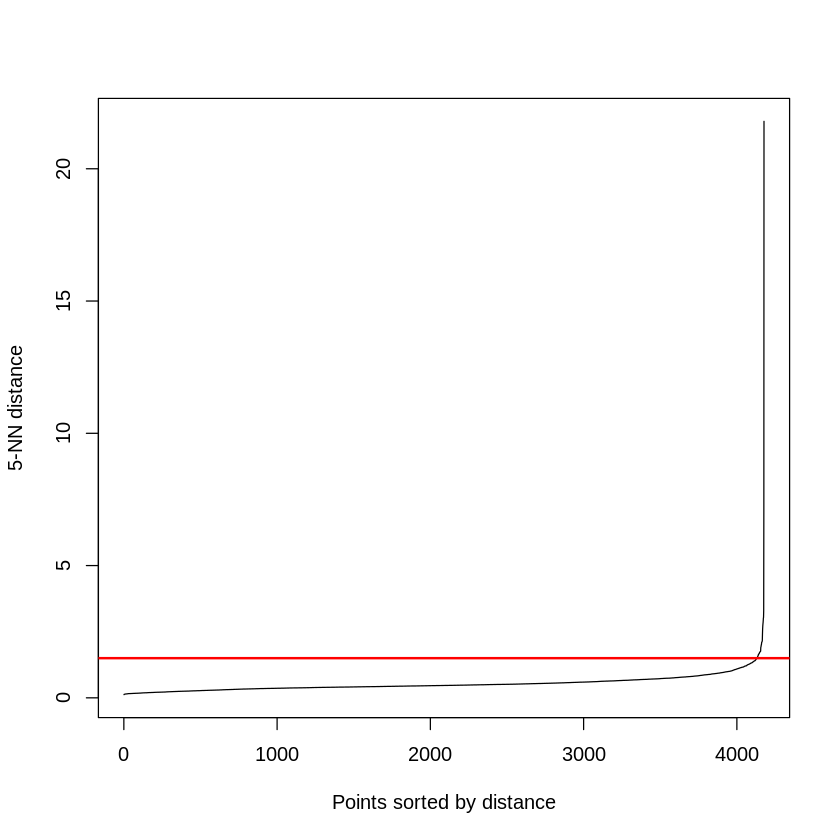

In [31]:
kNNdistplot(datos, k = 5)

abline(
  h = 1.5,
  col = "red",
  lwd = 2
)
modelo_dbscan <- dbscan(
  datos,
  eps = 1.5,
  minPts = 5
)

modelo_dbscan

Gráfico DBSCAN

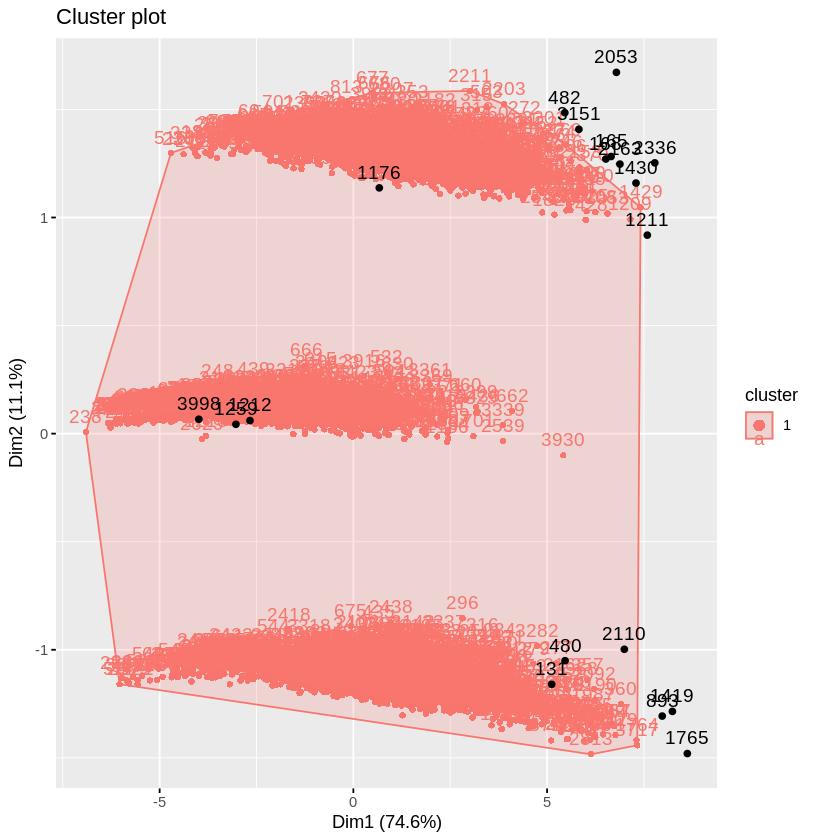

In [32]:
fviz_cluster(
  modelo_dbscan,
  data = datos
)



*   Se observan agrupaciones formadas en función de la densidad de los datos y la presencia de posibles observaciones atípicas que no pertenecen a ningún grupo definido.



Análisis de Componentes Principales (PCA)

Importance of components:
                         PC1    PC2     PC3     PC4     PC5     PC6     PC7
Standard deviation     2.591 1.0008 0.83295 0.50798 0.40727 0.29125 0.25115
Proportion of Variance 0.746 0.1113 0.07709 0.02867 0.01843 0.00943 0.00701
Cumulative Proportion  0.746 0.8572 0.93434 0.96301 0.98145 0.99087 0.99788
                           PC8     PC9
Standard deviation     0.11266 0.07998
Proportion of Variance 0.00141 0.00071
Cumulative Proportion  0.99929 1.00000

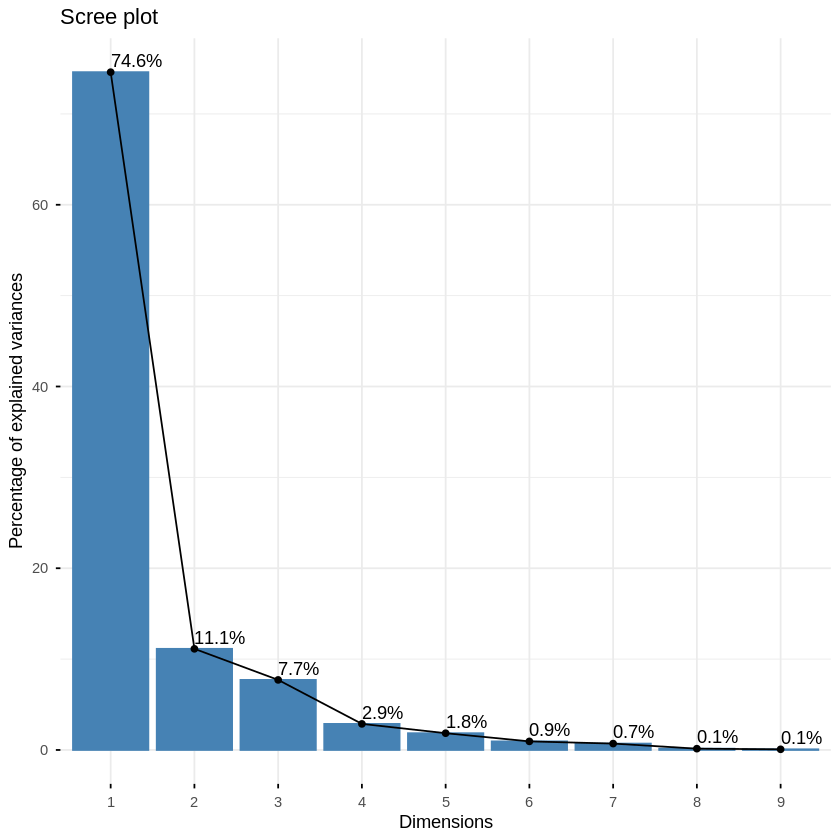

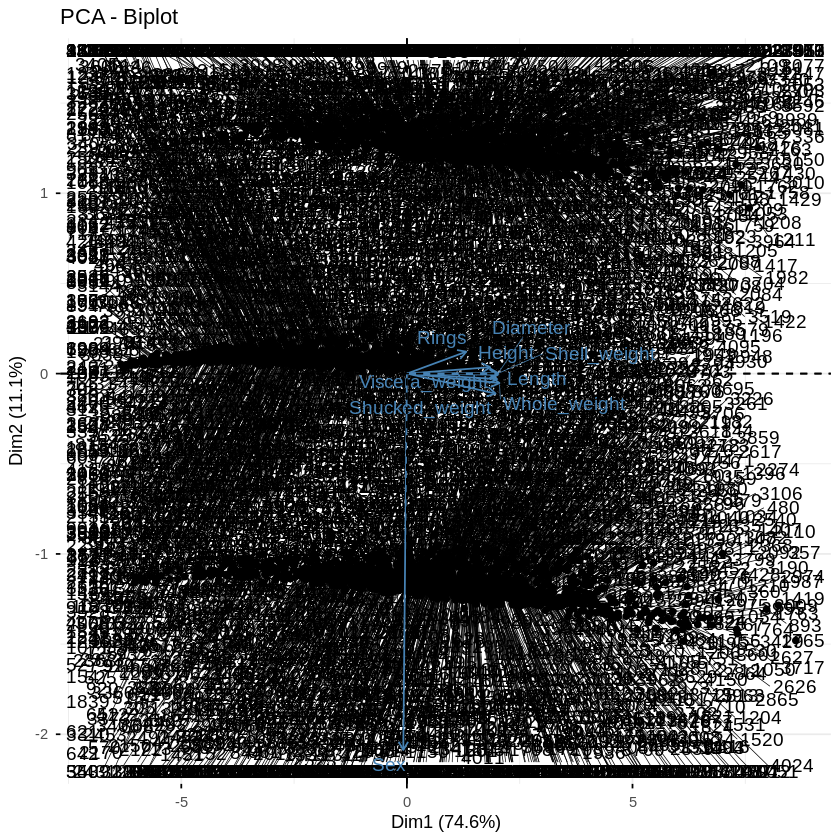

In [33]:
pca <- prcomp(
  datos,
  center = TRUE,
  scale = TRUE
)

summary(pca)

#Varianza explicada
fviz_eig(
  pca,
  addlabels = TRUE
)

#Biplot del PCA
fviz_pca_biplot(
  pca,
  repel = TRUE
)



*  **Componentes Principales (PCA)**:Se observa que los primeros componentes principales concentran gran parte de la variabilidad de los datos, permitiendo reducir la dimensionalidad sin perder información relevante.

*   **Biplot del PCA:** Se observa la relación entre las variables originales y los individuos analizados. Las variables asociadas al tamaño y al peso presentan una mayor contribución en la formación de los grupos.





t-SNE

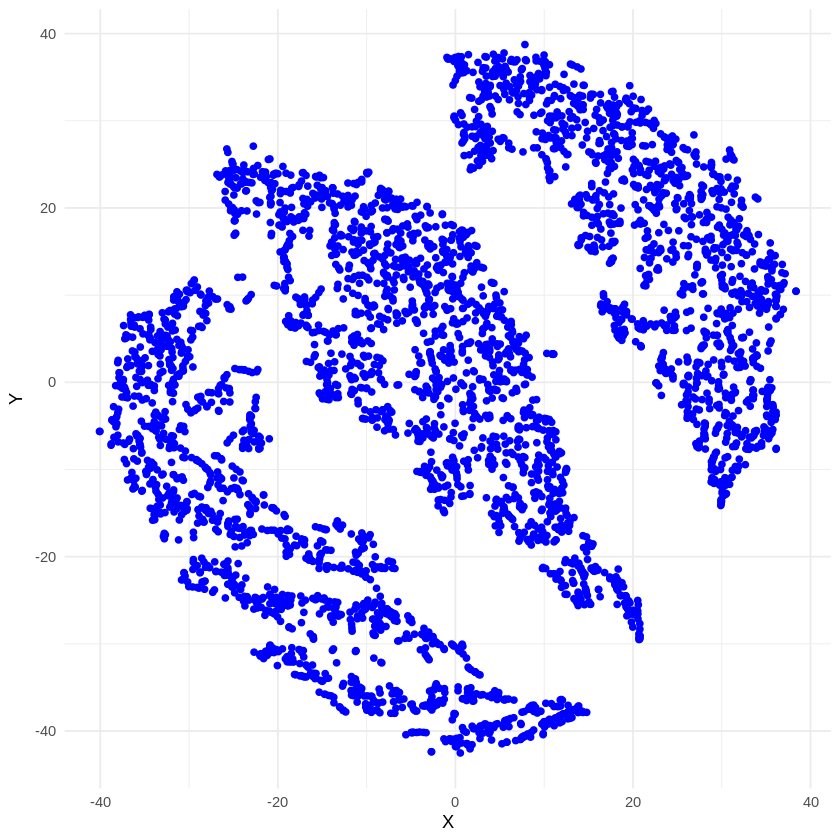

In [34]:
set.seed(123)

tsne <- Rtsne(
  datos,
  dims = 2,
  perplexity = 30
)

#Gráfico t-SNE
tsne_df <- data.frame(
  X = tsne$Y[,1],
  Y = tsne$Y[,2]
)

ggplot(
  tsne_df,
  aes(X,Y)
)+
geom_point(color="blue")+
theme_minimal()



*   Se observa una representación bidimensional de los datos que permite visualizar con mayor claridad la distribución y separación de los conglomerados encontrados.



Evaluación mediante Silhouette

  cluster size ave.sil.width
1       1 1176          0.47
2       2 1223          0.23
3       3 1778          0.27


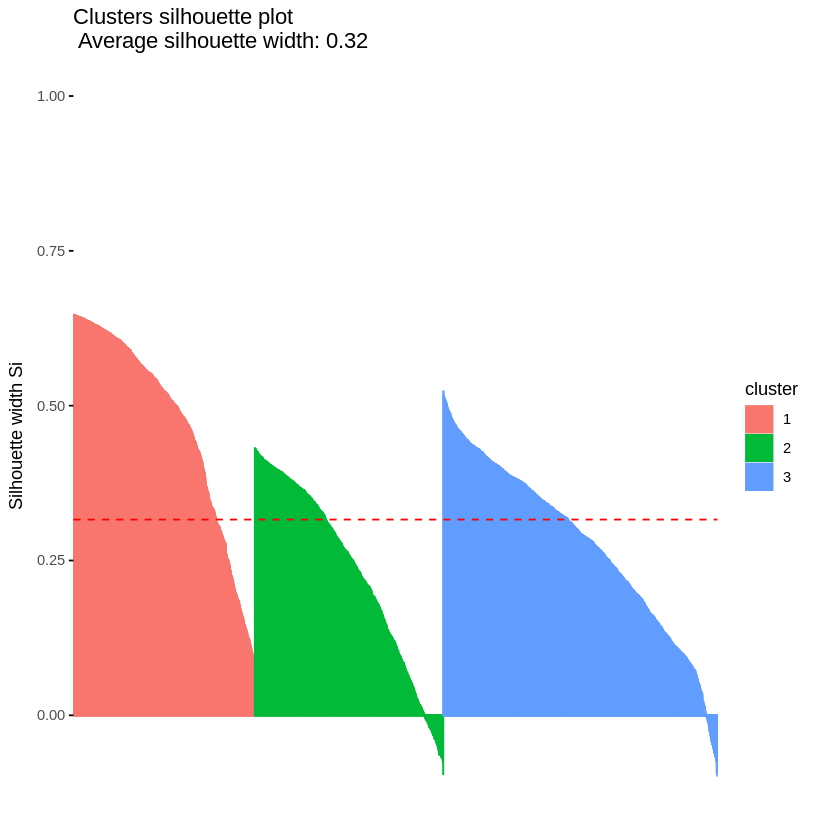

In [35]:
sil <- silhouette(
  modelo_kmeans$cluster,
  dist(datos)
)

fviz_silhouette(sil)



*   Se observa una adecuada separación y cohesión entre los clusters, lo que indica que la segmentación obtenida presenta una calidad aceptable.



Índice Calinski-Harabasz

In [36]:
intCriteria(
  as.matrix(datos),
  as.integer(modelo_kmeans$cluster),
  "Calinski_Harabasz"
)

$calinski_harabasz
[1] 3479.503



*   Se observa que los clusters presentan una adecuada separación entre grupos y una buena cohesión interna, indicando una segmentación de calidad.



Índice Jambu (Dunn)

In [37]:
intCriteria(
  as.matrix(datos),
  as.integer(modelo_kmeans$cluster),
  "Dunn"
)

$dunn
[1] 0.00713661



*   Se observa que los conglomerados presentan una separación moderada y cierto grado de superposición entre ellos; sin embargo, la segmentación obtenida permite identificar patrones naturales en los datos.





*   **Resultado esperado: Una segmentación clara de los datos y una interpretación de los grupos encontrados:**

Se logró una segmentación clara de la base de datos Abalone mediante técnicas de aprendizaje no supervisado, identificando tres conglomerados principales. La interpretación de los grupos encontrados indica que el **primer conglomerado** corresponde a abalones de menor tamaño y peso, el **segundo agrupa** individuos con características intermedias y el **tercero** está conformado por abalones de mayor tamaño y peso. Estas diferencias están determinadas principalmente por variables relacionadas con la longitud, el diámetro y los distintos tipos de peso, evidenciando la existencia de patrones naturales en la población estudiada.
En conclusión, las técnicas de clustering y reducción de dimensionalidad permitieron identificar patrones naturales en los datos y obtener una segmentación consistente y de buena calidad, proporcionando una mejor comprensión de las características físicas de los abalones analizados.

